The sum of the primes below 10 is 2+3+5+7=17. Find the summ of all the primes below two million.

In [6]:
n = 2_000_000
#from sympy import prime
#prime(148_933) # 1_999_993
from sympy import sieve # Desbloqueado derecho a usar sieve

# Primer intento:

uso de sieve de numpy

In [11]:
def primer_intento():
    return sum(sieve.primerange(n))
primer_intento()

142913828922

# Optimizacion:

chatgpt recomienda aprovechar la criba interna de sympy pero evitando el generador de `primerange`, extendiendo la sieve una sola vez y sumando directamente su lista interna de primos:

In [9]:
def optimizacion():
    sieve.extend(n) # exiende la lista del sieve (a más allá de 2_000_000, en hot-runs esto puede omitirse). Lo cual es mas eficiente porque la lista es la estructura interna cacheada     
    #return sum(sieve[1:sieve.search(n)[0] + 1]) # inicia desde 1. Además, puesto que a pesar de su eficiencia como _list es API interna de sympy, usar sieve[] es de hecho más estable o seguro
    return sum(sieve._list[:sieve.search(n)[0]]) # lista inicia desde 0 y el search[0] es exactamete 148_933-th primo que ocupamos
optimizacion()

142913828922

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 142913828922
Consistente: True
Repeticiones por corrida: 1
Tiempo promedio:  4.6994 ms
Tiempo mediano:   4.4728 ms
Tiempo minimo:    4.1939 ms
Tiempo stdev:     735.9115 us  (CV: 15.7%)
Memoria promedio: 1.1368 MB
Memoria mediana:  1.1368 MB
Memoria maxima:   1.1369 MB
Memoria stdev:    40.0000 B
Asignaciones (mediana): 3

--- Optimizacion ---
Resultado: 142913828922
Consistente: True
Repeticiones por corrida: 10
Tiempo promedio:  2.2292 ms
Tiempo mediano:   2.2187 ms
Tiempo minimo:    2.2025 ms
Tiempo stdev:     24.1018 us  (CV: 1.1%)
Memoria promedio: 1.1366 MB
Memoria mediana:  1.1366 MB
Memoria maxima:   1.1366 MB
Asignaciones (mediana): 3

=== Comparacion directa ===
Speedup en tiempo:    2.02x  (gana: Optimizacion)
Ratio de memoria:     1.00x  (gana: Optimizacion)
Ratio asignaciones:   empate (3)


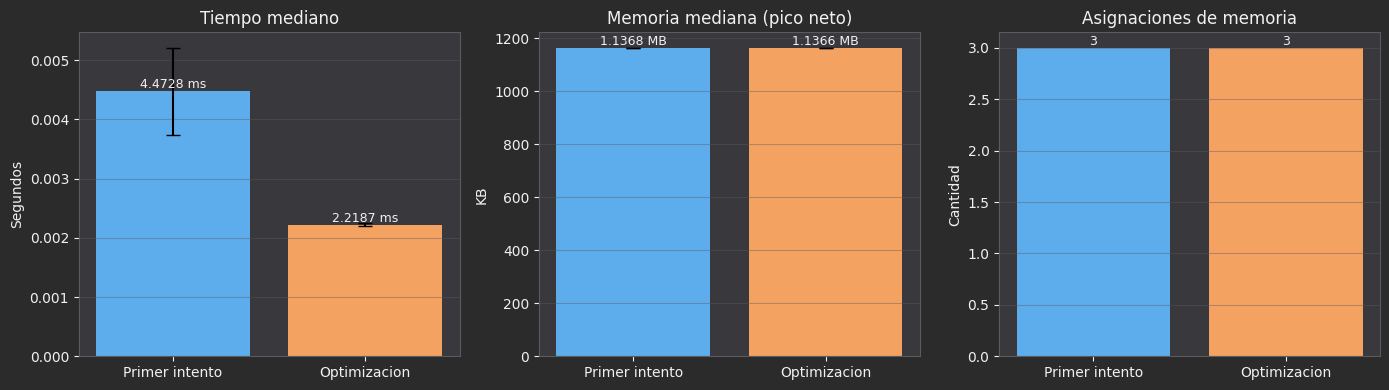

{'Primer intento': {'resultado': 142913828922,
  'consistente': True,
  'tiempos': [0.006409756000000044,
   0.004940020000000267,
   0.0043647999999998355,
   0.004193898000000029,
   0.004246004000000081,
   0.004235752000000037,
   0.004624274000000206,
   0.004580766000000125],
  'memorias': [1164.0703125, 1164.1484375, 1164.0703125, 1164.0703125],
  'asignaciones': [3, 4, 3, 3],
  'repeticiones': 1},
 'Optimizacion': {'resultado': 142913828922,
  'consistente': True,
  'tiempos': [0.0022630024000000136,
   0.0022025031000000085,
   0.0022580445000000005,
   0.0022162770999999636,
   0.002207847999999979,
   0.0022506080999999956,
   0.0022139396000000035,
   0.002221146900000015],
  'memorias': [1163.8359375, 1163.8359375, 1163.8359375, 1163.8359375],
  'asignaciones': [3, 3, 3, 3],
  'repeticiones': 10}}

In [12]:
from lib.utils import comparar_metodos

comparar_metodos(primer_intento, optimizacion)